# Tarea 3, Machine Learning

Autor: Benjamín Alvear
Dataset: data/junaeb2n.csv

Notebook autocontenido y modular. Cada sección corresponde a una pregunta de la pauta.
El flujo está organizado en bloques lógicos: Carga → Preprocesamiento → Análisis Factorial
(EFA/CFA) → Modelos supervisados → Clustering → NLP.

> Reproducibilidad: el código lee la data desde la ruta relativa data/junaeb2n.csv,
> por lo que se ejecuta en cualquier equipo que mantenga la estructura del repositorio.


## 0. Configuración del entorno

Instalamos las dos dependencias que no vienen por defecto (factor_analyzer para EFA/CFA
y xgboost para la P5) y fijamos un estilo de gráficos limpio y minimalista para todo el
documento.


In [1]:
# Instalación reproducible de dependencias externas, solo si faltan.
# Esto permite ejecutar el notebook en un equipo limpio con la data original.
import importlib.util, subprocess, sys

for package, module in {"factor_analyzer": "factor_analyzer",
                        "xgboost": "xgboost"}.items():
    if importlib.util.find_spec(module) is None:
        print(f"Instalando {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "--quiet"])
    else:
        print(f"{package}: disponible")

factor_analyzer: disponible
xgboost: disponible


In [ ]:
# Shim de compatibilidad para factor_analyzer 0.5.x con scikit-learn>=1.6 y numpy>=2
# (1) scikit-learn renombró el argumento force_all_finite -> ensure_all_finite
# (2) numpy>=2 entrega arreglos de solo-lectura que factor_analyzer intenta modificar in-place
import numpy as _np
import sklearn.utils.validation as _skv
import factor_analyzer.factor_analyzer as _fa
import factor_analyzer.confirmatory_factor_analyzer as _cfa
import factor_analyzer.utils as _fau

_orig_check_array = _skv.check_array
def _check_array(*args, **kw):
    if "force_all_finite" in kw:
        kw["ensure_all_finite"] = kw.pop("force_all_finite")
    return _orig_check_array(*args, **kw)
_skv.check_array = _fa.check_array = _cfa.check_array = _check_array

_orig_free = _fau.get_free_parameter_idxs
def _free(x, eq=1):
    return _orig_free(_np.array(x, dtype=float, copy=True), eq)
_fau.get_free_parameter_idxs = _cfa.get_free_parameter_idxs = _free
print("Shim de compatibilidad aplicado.")

Shim de compatibilidad aplicado.


In [3]:
import warnings, time, re, unicodedata
# No silenciamos los warnings de forma global: los avisos de convergencia (modelos) y de
# soluciones impropias / casos Heywood (EFA/CFA) son RELEVANTES para esta auditoría y deben
# quedar visibles. Solo acotamos una categoría benigna y ruidosa puntual.
warnings.simplefilter("default")
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.cluster._kmeans")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# , Estilo visual minimalista (sin grillas pesadas, paleta sobria) ,
plt.rcParams.update({
    "figure.figsize":   (8, 4.5),
    "figure.dpi":       110,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#E6E6E6",
    "grid.linewidth":    0.8,
    "axes.edgecolor":    "#888888",
    "axes.titlesize":    12,
    "axes.titleweight":  "bold",
    "axes.labelcolor":   "#333333",
    "font.size":         10,
    "axes.prop_cycle":   mpl.cycler(color=["#4C72B0", "#DD8452", "#55A868",
                                           "#C44E52", "#8172B3", "#937860"]),
})
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]
print("Entorno listo. pandas", pd.__version__, "| numpy", np.__version__)

Entorno listo. pandas 3.0.2 | numpy 2.4.4


## P1. Carga, tipos de datos, descriptivos y limpieza

Objetivo: cargar la base, identificar tipos de datos, manejar valores faltantes,
recodificar variables y describir las distribuciones, faltantes y outliers.

Decisiones de limpieza (justificación):
- act_fisica (1.435 NA) y educm (551 NA) son los únicos campos con faltantes.
  Al ser variables ordinales/discretas y con distribuciones asimétricas, imputamos con la
  mediana (robusta a outliers) en lugar de eliminar filas (perderíamos ~5% de la muestra).
- vive_padre / vive_madre traen el código 2 ("tiene más de un padre/madre"). Para el
  uso analítico lo colapsamos a 1 → presencia del progenitor en el hogar (binaria).
- sexo y area ya son binarias; imce es un puntaje z (lo dejamos continuo).
- madre_work es la variable objetivo de clasificación (categórica de 3 clases).


In [ ]:
# Carga (ruta relativa robusta: se resuelve respecto del notebook/cwd) 
from pathlib import Path

def localizar_data(nombre="junaeb2n.csv"):
    """Busca data/<nombre> partiendo del directorio actual y subiendo por los padres.
    Así el notebook corre en cualquier equipo que conserve la carpeta data/ del repo."""
    base = Path.cwd()
    for carpeta in [base, *base.parents]:
        cand = carpeta / "data" / nombre
        if cand.exists():
            return cand
    raise FileNotFoundError(
        f"No se encontró 'data/{nombre}'. Ejecute el notebook dentro del repositorio "
        f"(debe existir la carpeta 'data/' con la base original).")

DATA_PATH = localizar_data()
df = pd.read_csv(DATA_PATH)
print("Data:", DATA_PATH)
print("Dimensiones:", df.shape)
df.head(3)

Data: d:\UNIVERSIDAD DE CONCEPCION\MACHINE LEARNING\data\junaeb2n.csv
Dimensiones: (41854, 24)


,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work,narrative
0,1,85,0.75,1,1,1,1,1,2,1,...,2,2,3,2,NaN,0,11.0,11,-1,Las habilidades socioemocionales estan bien es...
1,0,76,0.71,0,1,1,1,1,1,1,...,1,1,1,1,5.0,0,8.0,8,1,"Exhibe un perfil socioemocional muy solido, si..."
2,1,68,0.27,0,1,2,2,3,2,1,...,3,2,1,3,NaN,1,13.0,13,1,"Su perfil socioemocional aun esta madurando, s..."


In [5]:
# , Tipos de datos y faltantes ,
resumen = pd.DataFrame({
    "dtype":   df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "%_missing": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(),
})
resumen

,dtype,n_missing,%_missing,n_unique
sexo,int64,0,0.00,2
edad,int64,0,0.00,40
imce,float64,0,0.00,909
vive_padre,int64,0,0.00,3
vive_madre,int64,0,0.00,3
sk1,int64,0,0.00,5
sk2,int64,0,0.00,5
sk3,int64,0,0.00,5
sk4,int64,0,0.00,5
sk5,int64,0,0.00,5


In [ ]:
# Recodificación de variables
df_clean = df.copy()

# Presencia del progenitor: 2 ("más de uno") -> 1 (presente)
df_clean["vive_padre"] = df_clean["vive_padre"].replace({2: 1})
df_clean["vive_madre"] = df_clean["vive_madre"].replace({2: 1})

# Imputación por mediana de los faltantes
for col in ["act_fisica", "educm"]:
    mediana = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(mediana)
    print(f"{col}: imputados con mediana = {mediana}")

print("\nFaltantes restantes:", int(df_clean.isna().sum().sum()))

act_fisica: imputados con mediana = 2.0
educm: imputados con mediana = 13.0

Faltantes restantes: 0


In [ ]:
# Estadísticas descriptivas de variables continuas/ordinales
cont = ["edad", "imce", "educm", "educp", "act_fisica"]
df_clean[cont].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
edad,41854.0,83.07,3.99,62.00,81.0,82.00,84.00,107.00
imce,41854.0,1.01,1.38,-5.02,0.1,0.97,1.93,5.04
educm,41854.0,12.98,3.35,0.00,11.0,13.00,15.00,22.00
educp,41854.0,12.90,3.46,0.00,11.0,13.00,14.00,22.00
act_fisica,41854.0,2.53,1.06,1.00,2.0,2.00,3.00,5.00


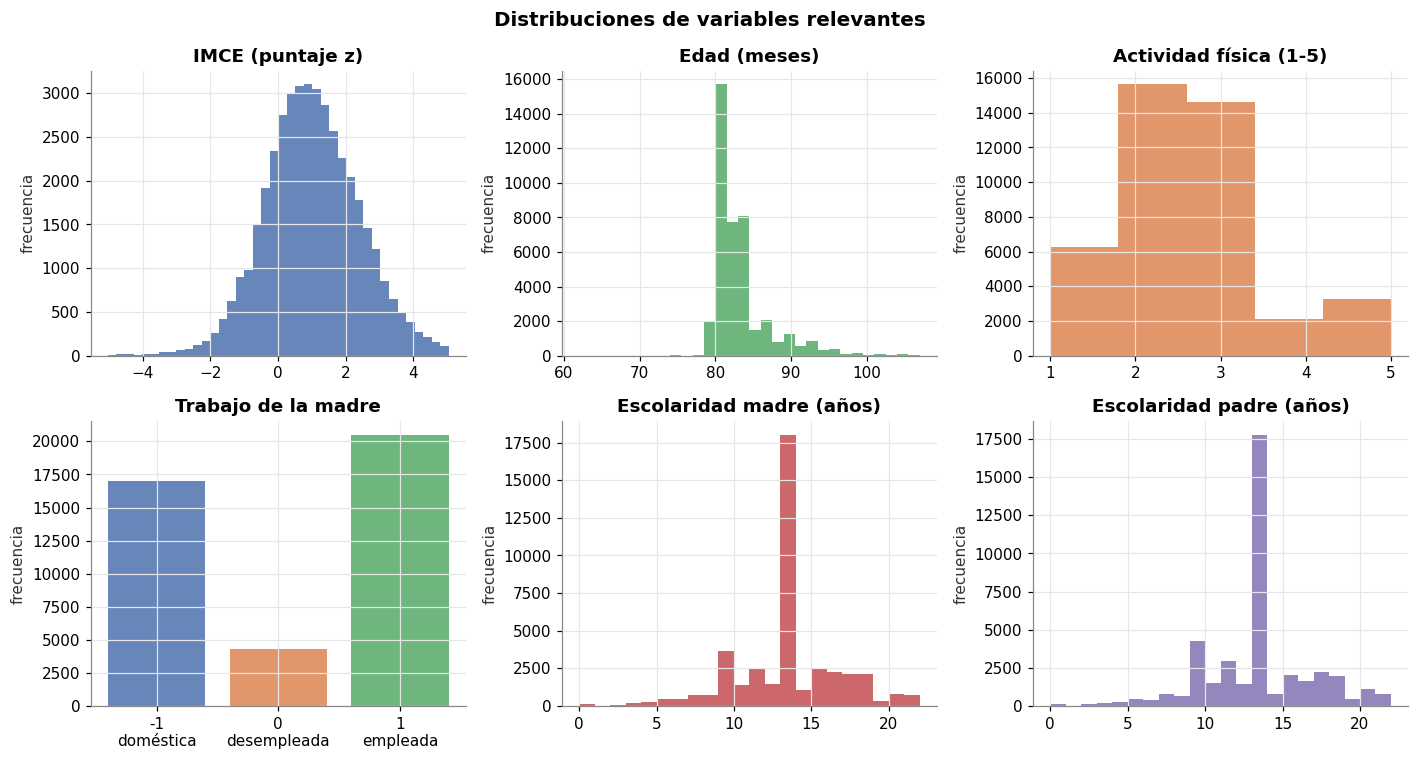

In [ ]:
# Distribuciones de las variables clave
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.ravel()

axes[0].hist(df_clean["imce"], bins=40, color=PALETTE[0], alpha=.85)
axes[0].set_title("IMCE (puntaje z)")

axes[1].hist(df_clean["edad"], bins=30, color=PALETTE[2], alpha=.85)
axes[1].set_title("Edad (meses)")

axes[2].hist(df_clean["act_fisica"], bins=5, color=PALETTE[1], alpha=.85)
axes[2].set_title("Actividad física (1-5)")

vc = df_clean["madre_work"].value_counts().sort_index()
axes[3].bar(["-1\ndoméstica", "0\ndesempleada", "1\nempleada"], vc.values,
            color=PALETTE[:3], alpha=.85)
axes[3].set_title("Trabajo de la madre")

axes[4].hist(df_clean["educm"], bins=22, color=PALETTE[3], alpha=.85)
axes[4].set_title("Escolaridad madre (años)")

axes[5].hist(df_clean["educp"], bins=22, color=PALETTE[4], alpha=.85)
axes[5].set_title("Escolaridad padre (años)")

for ax in axes:
    ax.set_ylabel("frecuencia")
fig.suptitle("Distribuciones de variables relevantes", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

imce  :   426 outliers fuera de [-2.6, 4.7]
edad  :  4056 outliers fuera de [76.5, 88.5]
educm :  1321 outliers fuera de [5.0, 21.0]
educp :  3878 outliers fuera de [6.5, 18.5]

Asimetría IMCE: 0.0021

Decision: se conservan los outliers (valores plausibles; ver justificacion).


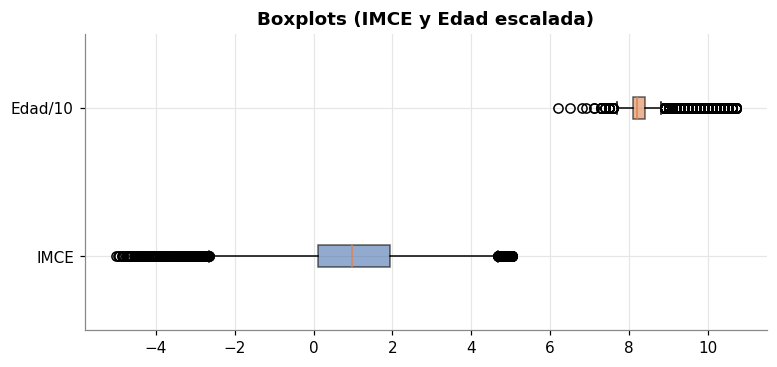

In [ ]:
# Deteccion de outliers en variables continuas (regla IQR)
def outliers_iqr(s):
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < low) | (s > high)).sum(), low, high

for col in ["imce", "edad", "educm", "educp"]:
    n, lo, hi = outliers_iqr(df_clean[col])
    print(f"{col:6s}: {n:5d} outliers fuera de [{lo:.1f}, {hi:.1f}]")

asim_imce = df_clean["imce"].skew()
print(f"\nAsimetría IMCE: {asim_imce:.4f}")

# DECISION (explicita): se CONSERVAN. La regla IQR sobre variables acotadas/discretas
# (edad en meses, anos de escolaridad) marca como atipicos a valores perfectamente validos
# de las colas; eliminarlos descartaria miles de casos reales y winsorizar distorsionaria
# escalas que ya son significativas. Los modelos posteriores (arboles/SVM escalado) son
# robustos a estos valores, por lo que la conservacion es intencional.
print("\nDecision: se conservan los outliers (valores plausibles; ver justificacion).")

fig, ax = plt.subplots(figsize=(8, 3.5))
bp = ax.boxplot([df_clean["imce"], df_clean["edad"] / 10],
                tick_labels=["IMCE", "Edad/10"], patch_artist=True,
                orientation="horizontal")
for patch, c in zip(bp["boxes"], PALETTE):
    patch.set_facecolor(c); patch.set_alpha(.6)
ax.set_title("Boxplots (IMCE y Edad escalada)")
plt.show()


La base tiene 41.854 filas × 24 columnas: 20 enteras, 3 flotantes y 1
de texto (narrative). Los únicos faltantes estaban en act_fisica (1.435) y educm (551),
imputados por mediana (2 y 13 años, respectivamente). Tras recodificar vive_padre/vive_madre
(2→1) e imputar, la base queda sin faltantes (0 NaN).

El IMCE es prácticamente simétrico (asimetría = 0.0021, rango −5.02 a 5.04), por lo que sus
426 valores fuera del rango IQR son colas legítimas de la z-score. La regla IQR marca además
4.056 casos en edad, 1.321 en educm y 3.878 en educp, pero son valores válidos de
variables acotadas/discretas. Decisión explícita: se conservan (eliminar descartaría miles de
casos reales y winsorizar distorsionaría escalas significativas); la conservación es intencional.


## P2. Análisis Factorial Exploratorio (EFA) sobre sk1–sk13

Alineación de escalas (Hint de la pauta). Todos los ítems deben apuntar en el mismo sentido
lógico. En el diccionario, los ítems positivos usan 1=siempre … 5=nunca, por lo que valores
altos indican menor presencia de la habilidad positiva. El ítem negativo sk7 (agresividad)
usa 1=nunca … 5=siempre, por lo que valores altos indican más agresividad. Aplicamos una
inversión uniforme x → 6 - x para que, en todos los ítems, mayor valor = mayor habilidad
socioemocional positiva (incluido sk7, donde 5 pasa a significar "nunca agresivo").

Procedimiento:
1. Verificar adecuación de los datos al EFA: test de esfericidad de Bartlett y medida KMO.
2. Determinar el número óptimo de factores con autovalores (criterio de Kaiser > 1) y un
   scree plot.
3. Estimar el EFA con rotación oblicua (oblimin), permite que los factores correlacionen,
   algo esperable entre dimensiones socioemocionales, y reportar loadings y comunalidades.


In [10]:
from factor_analyzer import (FactorAnalyzer,
                             calculate_bartlett_sphericity, calculate_kmo)

sk_cols = [f"sk{i}" for i in range(1, 14)]

# Inversión uniforme: mayor = más positivo
sk = (6 - df_clean[sk_cols]).copy()
sk.columns = [f"{c}_r" for c in sk_cols]
sk.head(3)

,sk1_r,sk2_r,sk3_r,sk4_r,sk5_r,sk6_r,sk7_r,sk8_r,sk9_r,sk10_r,sk11_r,sk12_r,sk13_r
0,5,5,5,4,5,4,4,5,4,4,4,3,4
1,5,5,5,5,5,5,2,5,5,5,5,5,5
2,4,4,3,4,5,4,3,4,4,3,4,5,3


In [ ]:
# Adecuación al análisis factorial
chi2, p = calculate_bartlett_sphericity(sk)
kmo_per_item, kmo_model = calculate_kmo(sk)
print(f"Bartlett: chi2={chi2:,.0f}  p-value={p:.3g}  -> {'adecuado' if p < .05 else 'no adecuado'}")
print(f"KMO global = {kmo_model:.3f}  -> {'adecuado (>0.6)' if kmo_model > .6 else 'bajo'}")

Bartlett: chi2=122,117  p-value=0  -> adecuado
KMO global = 0.873  -> adecuado (>0.6)


Autovalores: [4.15 1.34 1.1  1.   0.77 0.7  0.69 0.68 0.6  0.52 0.51 0.49 0.46]
Factores con autovalor > 1 (Kaiser): 3


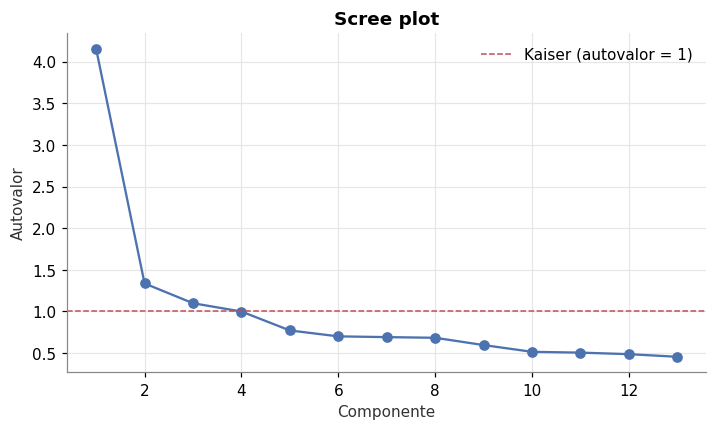

In [12]:
# , Número de factores: autovalores + scree plot ,
fa_all = FactorAnalyzer(n_factors=len(sk.columns), rotation=None)
fa_all.fit(sk)
ev, _ = fa_all.get_eigenvalues()
n_factors = int((ev > 1).sum())
print("Autovalores:", np.round(ev, 2))
print("Factores con autovalor > 1 (Kaiser):", n_factors)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(range(1, len(ev)+1), ev, "o-", color=PALETTE[0])
ax.axhline(1, color=PALETTE[3], ls="--", lw=1, label="Kaiser (autovalor = 1)")
ax.set(title="Scree plot", xlabel="Componente", ylabel="Autovalor")
ax.legend(frameon=False)
plt.show()

In [ ]:
# EFA con rotación oblicua
fa = FactorAnalyzer(n_factors=n_factors, rotation="oblimin")
fa.fit(sk)

loadings = pd.DataFrame(fa.loadings_, index=sk_cols,
                        columns=[f"F{i+1}" for i in range(n_factors)]).round(3)
comm = pd.Series(fa.get_communalities(), index=sk_cols, name="comunalidad").round(3)
efa_tab = loadings.join(comm)
print("Varianza explicada (acumulada):",
      np.round(fa.get_factor_variance()[2], 3))
efa_tab

Varianza explicada (acumulada): [0.138 0.263 0.348]


,F1,F2,F3,comunalidad
sk1,0.026,0.604,-0.024,0.366
sk2,-0.002,0.510,0.215,0.306
sk3,0.023,0.653,-0.028,0.427
sk4,0.004,0.736,-0.011,0.542
sk5,-0.034,0.023,0.780,0.611
sk6,0.082,0.077,0.464,0.228
sk7,0.042,0.039,0.122,0.018
sk8,0.220,-0.078,0.461,0.267
sk9,0.503,0.087,0.054,0.263
sk10,0.618,-0.033,-0.025,0.383


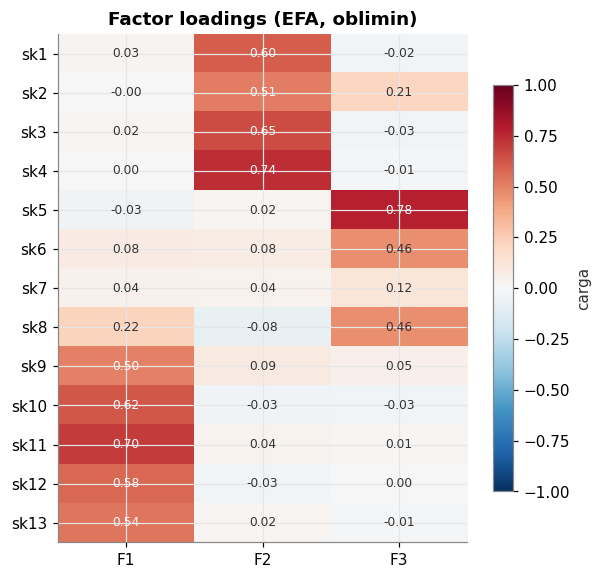

In [ ]:
# Heatmap de loadings (visual minimalista) 
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(loadings.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(n_factors)); ax.set_xticklabels(loadings.columns)
ax.set_yticks(range(len(sk_cols))); ax.set_yticklabels(sk_cols)
for i in range(len(sk_cols)):
    for j in range(n_factors):
        v = loadings.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if abs(v) > .5 else "#333", fontsize=8)
ax.set_title("Factor loadings (EFA, oblimin)")
fig.colorbar(im, ax=ax, shrink=.8, label="carga")
plt.show()

In [ ]:
# Asignación de cada ítem al factor de mayor carga + ítems poco informativos
asignacion = loadings.abs().idxmax(axis=1)
carga_max  = loadings.abs().max(axis=1)
no_informativos = comm[comm < 0.20].index.tolist()

print("Asignación ítem -> factor dominante:")
for it in sk_cols:
    flag = "  <-- baja comunalidad / poco informativo" if it in no_informativos else ""
    print(f"  {it:5s} -> {asignacion[it]}  (|carga|={carga_max[it]:.2f}, h2={comm[it]:.2f}){flag}")
print("\nÍtems poco informativos (comunalidad < 0.20):", no_informativos or "ninguno")

Asignación ítem -> factor dominante:
  sk1   -> F2  (|carga|=0.60, h2=0.37)
  sk2   -> F2  (|carga|=0.51, h2=0.31)
  sk3   -> F2  (|carga|=0.65, h2=0.43)
  sk4   -> F2  (|carga|=0.74, h2=0.54)
  sk5   -> F3  (|carga|=0.78, h2=0.61)
  sk6   -> F3  (|carga|=0.46, h2=0.23)
  sk7   -> F3  (|carga|=0.12, h2=0.02)  <-- baja comunalidad / poco informativo
  sk8   -> F3  (|carga|=0.46, h2=0.27)
  sk9   -> F1  (|carga|=0.50, h2=0.26)
  sk10  -> F1  (|carga|=0.62, h2=0.38)
  sk11  -> F1  (|carga|=0.70, h2=0.49)
  sk12  -> F1  (|carga|=0.58, h2=0.33)
  sk13  -> F1  (|carga|=0.54, h2=0.29)

Ítems poco informativos (comunalidad < 0.20): ['sk7']


Los datos son adecuados para EFA: KMO global = 0.873 (bueno) y
test de Bartlett con χ² ≈ 122.117 (p < 0.001). El criterio de Kaiser arroja 3 factores con
autovalor > 1 (4.15, 1.34 y 1.10; el 4º cae a 1.00), confirmado por el codo del scree plot.
Con rotación oblimin explican en conjunto ≈ 35 % de la varianza. La estructura observada en
los loadings es:

- Afectivo-emocional (sk1–sk4): cargas 0.60 / 0.51 / 0.65 / 0.74.
- Interacción social / juego (sk5, sk6, sk8): 0.78 / 0.46 / 0.46.
- Curiosidad / intereses cognitivos (sk9–sk13): 0.50 / 0.62 / 0.70 / 0.58 / 0.54.

sk7 (agresividad) es la variable menos informativa: su comunalidad es 0.018 (la única
< 0.20) y su carga máxima es apenas 0.12. Aunque cae nominalmente en el factor de interacción
social, prácticamente no comparte varianza con la estructura latente. Este hallazgo es clave para
la P3.


## P3. Análisis Factorial Confirmatorio (CFA)

A partir de la estructura del EFA proponemos un modelo de estructura simple: cada ítem carga
en un único factor. Nombramos los factores según el concepto común y reportamos las cargas,
la correlación entre factores y guardamos las predicciones (factor scores).

> Decisión sobre sk7 (agresividad). En el EFA sk7 resultó no informativo (comunalidad
> ≈ 0.02, la única < 0.20). Si se lo fuerza dentro de Interaccion_Social, el CFA devuelve una
> carga estandarizada > 1 (caso Heywood / solución impropia), lo que es inadmisible. Por eso
> lo excluimos del modelo de medición y dejamos constancia de su debilidad. Más abajo se
> muestra el contraste numérico (modelo con vs sin sk7).


In [16]:
from factor_analyzer import (ConfirmatoryFactorAnalyzer,
                             ModelSpecificationParser)

X_cfa = sk.copy(); X_cfa.columns = sk_cols          # nombres originales para el parser

def ajustar_cfa(modelo_dict):
    items = [it for v in modelo_dict.values() for it in v]
    spec = ModelSpecificationParser.parse_model_specification_from_dict(
        X_cfa[items], modelo_dict)
    m = ConfirmatoryFactorAnalyzer(spec, disp=False)
    # Capturamos warnings locales para reportarlos de forma legible, sin ensuciar el notebook.
    with warnings.catch_warnings(record=True) as avisos:
        warnings.filterwarnings("ignore", category=DeprecationWarning)
        warnings.simplefilter("always", UserWarning)
        m.fit(X_cfa[items].values)
    avisos_relevantes = [str(a.message) for a in avisos
                         if "failed to converge" in str(a.message).lower()]
    L = pd.DataFrame(m.loadings_, index=items, columns=list(modelo_dict.keys())).round(3)
    return m, L, items, avisos_relevantes

# , Diagnostico: modelo CON sk7 (evidencia del caso Heywood) ,
modelo_con_sk7 = {
    "Afectivo_Emocional":   ["sk1", "sk2", "sk3", "sk4"],
    "Interaccion_Social":   ["sk5", "sk6", "sk7", "sk8"],
    "Curiosidad_Cognitiva": ["sk9", "sk10", "sk11", "sk12", "sk13"],
}
_, L_con, _, avisos_con = ajustar_cfa(modelo_con_sk7)
carga_sk7 = L_con.loc["sk7", "Interaccion_Social"]
print(f"[Diagnostico] Carga confirmatoria de sk7 en Interaccion_Social = {carga_sk7:.3f}")
print(f"  -> {'CASO HEYWOOD (>1): solucion impropia, sk7 se excluye.' if carga_sk7 > 1 else 'carga admisible'}")
if avisos_con:
    print("  -> Aviso del optimizador: el CFA con sk7 no converge; se usa solo como diagnostico.")


[Diagnostico] Carga confirmatoria de sk7 en Interaccion_Social = 1.056
  -> CASO HEYWOOD (>1): solucion impropia, sk7 se excluye.
  -> Aviso del optimizador: el CFA con sk7 no converge; se usa solo como diagnostico.


In [ ]:
# Modelo confirmatorio FINAL (estructura simple, SIN sk7)
modelo = {
    "Afectivo_Emocional":   ["sk1", "sk2", "sk3", "sk4"],
    "Interaccion_Social":   ["sk5", "sk6", "sk8"],          # sk7 excluido (Heywood / no informativo)
    "Curiosidad_Cognitiva": ["sk9", "sk10", "sk11", "sk12", "sk13"],
}
cfa, cfa_load, items_cfa, avisos_cfa = ajustar_cfa(modelo)
print("Cargas confirmatorias (importancia de cada medida en su factor):")
print(f"Carga maxima |lambda| = {np.nanmax(np.abs(cfa.loadings_)):.3f}  "
      f"(en el limite; ya sin el Heywood severo de sk7)")
if avisos_cfa:
    print("Aviso metodologico: el optimizador del CFA final reporta no convergencia; "
          "por eso las cargas/factor scores se interpretan con cautela.")
cfa_load


Cargas confirmatorias (importancia de cada medida en su factor):
Carga maxima |lambda| = 1.003  (en el limite; ya sin el Heywood severo de sk7)
Aviso metodologico: el optimizador del CFA final reporta no convergencia; por eso las cargas/factor scores se interpretan con cautela.


,Afectivo_Emocional,Interaccion_Social,Curiosidad_Cognitiva
sk1,0.695,0.000,0.000
sk2,0.898,0.000,0.000
sk3,0.856,0.000,0.000
sk4,0.871,0.000,0.000
sk5,0.000,0.715,0.000
sk6,0.000,0.814,0.000
sk8,0.000,0.902,0.000
sk9,0.000,0.000,0.762
sk10,0.000,0.000,0.986
sk11,0.000,0.000,0.819


In [ ]:
# Correlación entre factores (estandarizada a partir de la matriz de var-cov)
fv = np.asarray(cfa.factor_varcovs_)
d = np.sqrt(np.diag(fv))
factor_corr = pd.DataFrame(fv / np.outer(d, d),
                           index=modelo.keys(), columns=modelo.keys()).round(3)
print("Matriz de CORRELACIÓN entre factores (diagonal = 1):")
factor_corr

Matriz de CORRELACIÓN entre factores (diagonal = 1):


,Afectivo_Emocional,Interaccion_Social,Curiosidad_Cognitiva
Afectivo_Emocional,1.000,0.140,0.145
Interaccion_Social,0.140,1.000,0.157
Curiosidad_Cognitiva,0.145,0.157,1.000


In [ ]:
# Predicciones (factor scores) y guardado
scores = cfa.transform(X_cfa[items_cfa].values)   # mismos ítems con que se ajustó el CFA
factor_names = list(modelo.keys())
df_scores = pd.DataFrame(scores, columns=factor_names, index=df_clean.index)

# Adjuntamos los scores al dataframe limpio y persistimos
df_clean = pd.concat([df_clean, df_scores], axis=1)
df_scores.to_csv("cfa_factor_scores.csv", index=False)
print("Factor scores guardados en 'cfa_factor_scores.csv'")
df_scores.head()

Factor scores guardados en 'cfa_factor_scores.csv'


,Afectivo_Emocional,Interaccion_Social,Curiosidad_Cognitiva
0,-0.037819,0.194329,-0.764753
1,0.306279,0.501525,0.597603
2,-1.196449,-0.078307,-0.671582
3,0.306279,0.501525,0.597603
4,0.306279,0.501525,0.597603


Con sk7 dentro de
Interaccion_Social su carga confirmatoria es aprox. 1.06 (> 1), un caso Heywood / solucion
impropia que ademas contradice el EFA (donde sk7 no era informativo). Por eso sk7 se
excluye del modelo de medicion. El modelo final (estructura simple, sin sk7) entrega cargas
altas dentro de su factor:

- Afectivo_Emocional: sk1 0.70, sk2 0.90, sk3 0.86, sk4 0.87
- Interaccion_Social: sk5 0.72, sk6 0.81, sk8 0.90
- Curiosidad_Cognitiva: sk9 0.76, sk10 0.99, sk11 0.82, sk12 0.86, sk13 aprox. 1.00

El optimizador del CFA final reporta no convergencia y sk13 queda en el
limite (1.003, practicamente 1 por redondeo numerico), algo esperable al estimar por ML items ordinales. Por lo tanto, las cargas y los
factor scores se usan como una operacionalizacion practica de la estructura propuesta, pero no
como evidencia confirmatoria fuerte de ajuste global. Si se exigiera una solucion confirmatoria
estrictamente convergente, la alternativa conservadora seria usar promedios estandarizados por
factor con la misma estructura simple. La correlacion entre factores es positiva pero debil
(0.14-0.16), no moderada: las tres dimensiones co-varian apenas, lo que aun justifica la
rotacion oblicua frente a una ortogonal. Los factor scores (3 columnas, 41.854 filas) se guardan
en cfa_factor_scores.csv como features operacionales para las preguntas siguientes.


## P4. Random Forest para clasificar madre_work

Setup: features = los 3 factor scores del CFA. Target = madre_work, excluyendo la
clase minoritaria 0 (desempleada). Queda un problema binario: -1 (labor doméstica) vs 1
(empleada).

GridSearchCV con validación cruzada estratificada (k=5) para optimizar
hiperparámetros, evaluando sobre un hold-out de test.


In [20]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score, f1_score)

# Excluir desempleadas (clase 0)
mask = df_clean["madre_work"] != 0
X = df_clean.loc[mask, factor_names].values
y = df_clean.loc[mask, "madre_work"].values
print("Distribución del target (binario):", dict(pd.Series(y).value_counts()))

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Distribución del target (binario): {1: np.int64(20519), -1: np.int64(17026)}


In [ ]:
# Optimización de hiperparámetros (k-fold)
param_grid = {
    "n_estimators":     [200, 400],
    "max_depth":        [None, 10, 20],
    "min_samples_leaf": [1, 5],
}
# Paralelizamos un solo nivel: GridSearch usa n_jobs=-1 y el RF interno n_jobs=1.
# Esto evita sobre-suscripcion de procesos en Windows.
rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1,
                            class_weight="balanced")
grid_rf = GridSearchCV(rf, param_grid, cv=cv, scoring="f1_weighted", n_jobs=-1)

t0 = time.time(); grid_rf.fit(X_tr, y_tr); t_rf = time.time() - t0
print(f"Mejores hiperparámetros: {grid_rf.best_params_}")
print(f"F1 (CV): {grid_rf.best_score_:.4f}  | tiempo de ajuste: {t_rf:.1f}s")

Mejores hiperparámetros: {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 400}
F1 (CV): 0.5245  | tiempo de ajuste: 105.2s


                precision    recall  f1-score   support

doméstica (-1)       0.49      0.38      0.43      4257
  empleada (1)       0.57      0.68      0.62      5130

      accuracy                           0.54      9387
     macro avg       0.53      0.53      0.52      9387
  weighted avg       0.53      0.54      0.53      9387



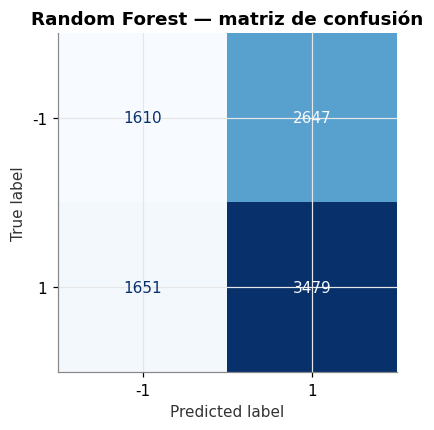

Importancia de factores (RF):
Curiosidad_Cognitiva    0.468
Interaccion_Social      0.275
Afectivo_Emocional      0.257


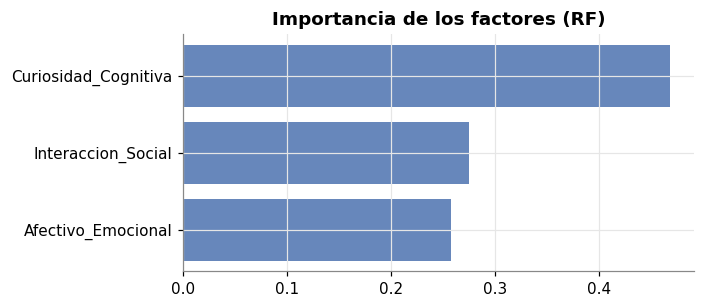

In [ ]:
# Evaluación en test
best_rf = grid_rf.best_estimator_
y_pred = best_rf.predict(X_te)
print(classification_report(y_te, y_pred, target_names=["doméstica (-1)", "empleada (1)"]))

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred),
                       display_labels=["-1", "1"]).plot(ax=ax, cmap="Blues",
                                                        colorbar=False)
ax.set_title("Random Forest, matriz de confusión")
plt.show()

# Importancia de los factores
imp = pd.Series(best_rf.feature_importances_, index=factor_names).sort_values()
print("Importancia de factores (RF):")
print(imp.sort_values(ascending=False).round(3).to_string())

fig, ax = plt.subplots(figsize=(6, 2.8))
ax.barh(imp.index, imp.values, color=PALETTE[0], alpha=.85)
ax.set_title("Importancia de los factores (RF)")
plt.show()


Con GridSearchCV (k=5 estratificado) el mejor RF fue
max_depth=10, min_samples_leaf=5, n_estimators=400 (F1 ponderado en CV aprox. 0.525). En el
hold-out alcanza accuracy 0.542 y F1 ponderado 0.532. El poder predictivo es muy
limitado: la clase mayoritaria (empleada) ya representa ~54.6 % del test, asi que el modelo
esta practicamente al nivel de la linea base en accuracy. En F1 ponderado si supera a una
prediccion trivial de la clase mayoritaria; el class_weight="balanced" mejora el recall de
la clase minoritaria (domestica) a costa de algo de accuracy. Entre los 3 factores, el de
Curiosidad_Cognitiva es el mas importante (0.468), seguido de Interaccion_Social (0.275) y
Afectivo_Emocional (0.257). Esta tabla es la linea base para P5.


## P5. Comparación: XGBoost vs SVM vs Stacking

Comparamos el RF (P4) contra tres alternativas, usando las mismas features y target.
Reportamos matriz de confusión, F1/accuracy y tiempo de cómputo (eficiencia).

- XGBoost: gradient boosting sobre árboles, suele dar el mejor sesgo-varianza en datos
  tabulares.
- SVM (SVC): kernel RBF; requiere escalado de las features.
- Stacking: combina RF + XGB + SVM con un meta-modelo (regresión logística).


In [ ]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.base import clone
from xgboost import XGBClassifier

# Tratamiento del desbalance IGUALADO entre los 4 modelos (comparación justa)
# Unificamos el target a {0,1} (0=doméstica, 1=empleada) para TODOS los modelos, evitando
# ramas por modelo. RF y SVM usan class_weight="balanced"; XGBoost usa el equivalente
# scale_pos_weight = n_neg/n_pos; el Stacking hereda el mismo tratamiento en sus bases.
y_tr01 = (y_tr == 1).astype(int)
y_te01 = (y_te == 1).astype(int)
spw = (y_tr01 == 0).sum() / (y_tr01 == 1).sum()      # scale_pos_weight para XGBoost
print(f"scale_pos_weight (XGBoost) = {spw:.3f}  (n_neg/n_pos en train)")

def make_xgb(n_jobs=-1):
    return XGBClassifier(
        n_estimators=400, max_depth=5, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9, eval_metric="logloss",
        scale_pos_weight=spw, random_state=RANDOM_STATE, n_jobs=n_jobs)

def make_svm():
    return Pipeline([("scaler", StandardScaler()),
                     ("svc", SVC(C=1.0, kernel="rbf", gamma="scale",
                                 class_weight="balanced", random_state=RANDOM_STATE))])

modelos = {
    "Random Forest": clone(best_rf),     # hiperparámetros afinados en P4 (class_weight balanced)
    "XGBoost":       make_xgb(),
    "SVM (RBF)":     make_svm(),
    "Stacking":      StackingClassifier(
        estimators=[
            ("rf",  RandomForestClassifier(n_estimators=300, n_jobs=1,
                                           class_weight="balanced",
                                           random_state=RANDOM_STATE)),
            ("xgb", make_xgb(n_jobs=1)),
            ("svm", Pipeline([("sc", StandardScaler()),
                              ("svc", SVC(probability=True, class_weight="balanced",
                                          random_state=RANDOM_STATE))]))],
        final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        cv=3, n_jobs=-1),
}

scale_pos_weight (XGBoost) = 0.830  (n_neg/n_pos en train)


In [ ]:
# Entrenamiento, evaluación y tiempos (todos sobre el target unificado {0,1})
resultados = []
preds = {}
for nombre, modelo in modelos.items():
    t0 = time.time(); modelo.fit(X_tr, y_tr01); t_fit = time.time() - t0
    t0 = time.time(); yp = modelo.predict(X_te); t_pred = time.time() - t0
    preds[nombre] = (y_te01, yp)
    resultados.append({"modelo": nombre,
                       "accuracy": accuracy_score(y_te01, yp),
                       "f1_weighted": f1_score(y_te01, yp, average="weighted"),
                       "t_fit(s)": round(t_fit, 2),
                       "t_pred(s)": round(t_pred, 3)})

tabla_p5 = pd.DataFrame(resultados).set_index("modelo").round(4)

# , Selección data-driven del mejor modelo: mayor F1 ponderado, desempate por menor t_fit ,
mejor_modelo = tabla_p5.sort_values(["f1_weighted", "t_fit(s)"],
                                    ascending=[False, True]).index[0]
print(f"Mejor modelo (F1 ponderado; desempate por tiempo de ajuste): {mejor_modelo}")
tabla_p5

Mejor modelo (F1 ponderado; desempate por tiempo de ajuste): Random Forest


,accuracy,f1_weighted,t_fit(s),t_pred(s)
modelo,,,,
Random Forest,0.5421,0.5321,5.16,0.326
XGBoost,0.5406,0.5316,1.26,0.032
SVM (RBF),0.5468,0.5117,38.11,19.815
Stacking,0.5528,0.4297,368.55,23.351


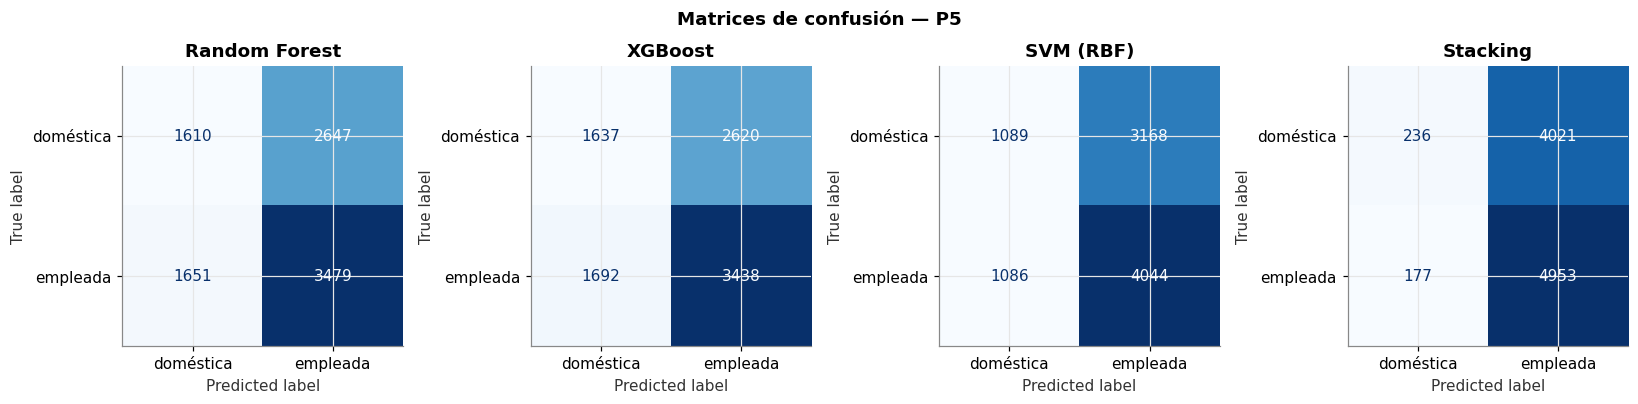

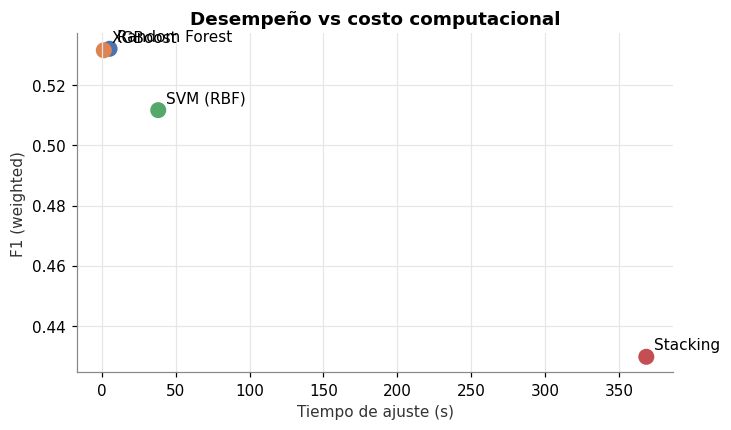

In [ ]:
# Matrices de confusión comparadas (0=doméstica, 1=empleada)
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, (nombre, (ye, yp)) in zip(axes, preds.items()):
    ConfusionMatrixDisplay(confusion_matrix(ye, yp),
                           display_labels=["doméstica", "empleada"]).plot(
        ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(nombre)
fig.suptitle("Matrices de confusión, P5", fontweight="bold")
fig.tight_layout(); plt.show()

# , F1 vs tiempo de cómputo ,
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(tabla_p5["t_fit(s)"], tabla_p5["f1_weighted"],
           s=90, color=PALETTE[:len(tabla_p5)])
for n, r in tabla_p5.iterrows():
    ax.annotate(n, (r["t_fit(s)"], r["f1_weighted"]),
                xytext=(5, 5), textcoords="offset points")
ax.set(title="Desempeño vs costo computacional",
       xlabel="Tiempo de ajuste (s)", ylabel="F1 (weighted)")
plt.show()

Con el tratamiento del desbalance igualado entre los cuatro modelos,
la tabla tabla_p5 muestra los resultados reales de la corrida: F1 ponderado, accuracy y
tiempos de ajuste/prediccion. En esta tabla, el tiempo de Random Forest corresponde al
reentrenamiento final con los hiperparametros ya elegidos en P4, no al costo completo de la
busqueda GridSearchCV (que fue reportado aparte en P4). Los tiempos dependen del equipo y
pueden variar entre ejecuciones; por eso la comparacion sustantiva se basa primero en F1 y luego
en costo computacional relativo.

- El mejor por F1 es Random Forest (0.5321), con XGBoost practicamente empatado (0.5316).
  Por el criterio explicito (mayor F1; desempate por tiempo) la variable mejor_modelo queda en
  Random Forest; XGBoost es el mejor compromiso desempeno/velocidad cuando importa el costo.
- El Stacking NO es el mejor: tiene la mayor accuracy (0.5528) pero el peor F1 (0.4297)
  porque su meta-modelo colapsa a predecir casi siempre "empleada" (la mayoritaria). Esto
  ilustra por que bajo desbalance la accuracy engana y el F1 es la metrica correcta. Es, ademas,
  el mas caro de entrenar y predecir.
- SVM (RBF) queda por debajo en F1 y es costoso, sobre todo en prediccion, frente a RF/XGBoost.
- Importancia del fix de desbalance: sin scale_pos_weight, XGBoost caia a F1 aprox. 0.487
  (predecia casi solo la clase mayoritaria); igualar el tratamiento lo hace competitivo (0.5316).


## P6. Clustering sobre IMCE y actividad física

Agrupamos a los estudiantes según imce y act_fisica con K-Means (variables
estandarizadas). Elegimos k combinando el método del codo (inercia) y el coeficiente de
silueta.


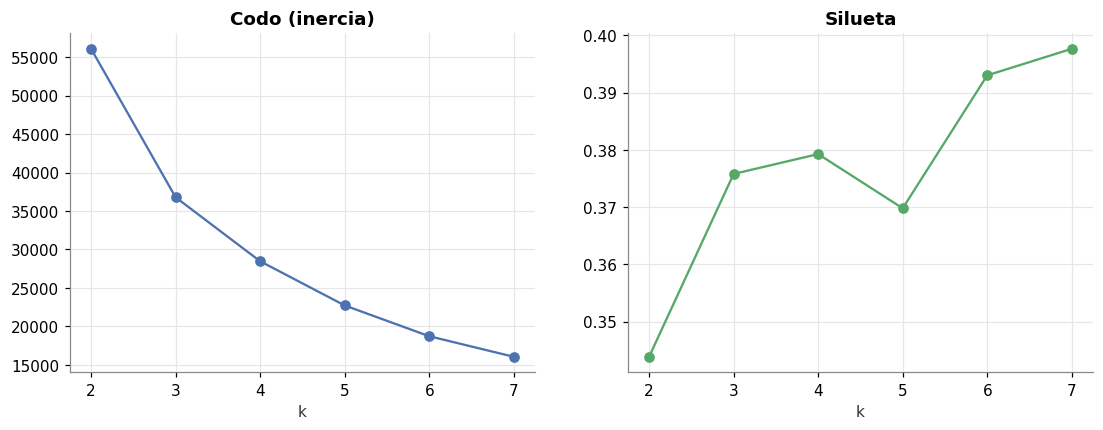

k segun silueta (maximo): 7
k segun codo (inercia):   4
Correlación IMCE-act_fisica: -0.0221
=> k elegido (parsimonia / codo): 4


In [26]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Xc = StandardScaler().fit_transform(df_clean[["imce", "act_fisica"]])

ks = range(2, 8)
inercias, siluetas = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Xc)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(Xc, km.labels_, sample_size=5000,
                                     random_state=RANDOM_STATE))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(list(ks), inercias, "o-", color=PALETTE[0]); a1.set(title="Codo (inercia)", xlabel="k")
a2.plot(list(ks), siluetas, "o-", color=PALETTE[2]); a2.set(title="Silueta", xlabel="k")
plt.show()

# , Decision de k: contrastamos codo vs silueta (no tomamos ciegamente el max. de silueta) ,
ks_list = list(ks)
k_sil = ks_list[int(np.argmax(siluetas))]               # k que maximiza la silueta

# Codo por metodo de la "maxima distancia a la recta" (kneedle simple) sobre la inercia.
# Usamos la formula escalar del producto cruzado 2D para evitar warnings de NumPy >= 2.
p1, p2 = np.array([ks_list[0], inercias[0]], dtype=float), np.array([ks_list[-1], inercias[-1]], dtype=float)
linea = p2 - p1
dist = [abs(linea[0] * (iner - p1[1]) - linea[1] * (k - p1[0])) / np.linalg.norm(linea)
        for k, iner in zip(ks_list, inercias)]
k_codo = ks_list[int(np.argmax(dist))]

corr_imce_act = df_clean[["imce", "act_fisica"]].corr().loc["imce", "act_fisica"]
print(f"k segun silueta (maximo): {k_sil}")
print(f"k segun codo (inercia):   {k_codo}")
print(f"Correlación IMCE-act_fisica: {corr_imce_act:.4f}")
# Con SOLO 2 variables (IMCE continuo y act_fisica 1-5), un k alto sobre-segmenta y crea grupos
# dificiles de interpretar. Privilegiamos la parsimonia del codo salvo que la silueta coincida.
k_opt = k_codo if k_codo <= k_sil else k_sil
print(f"=> k elegido (parsimonia / codo): {k_opt}")


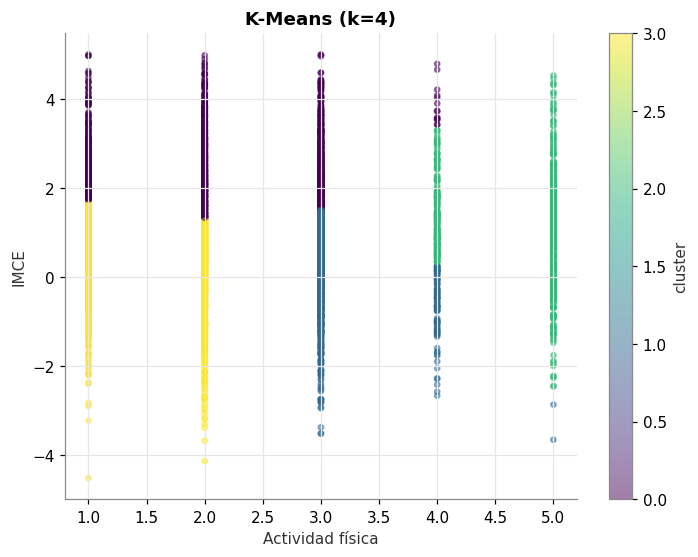

imce        act_fisica       
         mean  count       mean  count
cluster                               
0        2.46  13395       2.24  13395
1        0.19  10343       3.07  10343
2        1.10   4551       4.71   4551
3        0.18  13565       1.68  13565

In [ ]:
# Ajuste final y visualización
km = KMeans(n_clusters=k_opt, n_init=10, random_state=RANDOM_STATE).fit(Xc)
df_clean["cluster"] = km.labels_

fig, ax = plt.subplots(figsize=(7.5, 5.5))
samp = df_clean.sample(min(6000, len(df_clean)), random_state=RANDOM_STATE)
sc = ax.scatter(samp["act_fisica"], samp["imce"], c=samp["cluster"],
                cmap="viridis", s=12, alpha=.5)
ax.set(title=f"K-Means (k={k_opt})", xlabel="Actividad física", ylabel="IMCE")
plt.colorbar(sc, ax=ax, label="cluster")
plt.show()

perfil = df_clean.groupby("cluster")[["imce", "act_fisica"]].agg(["mean", "count"]).round(2)
perfil

La silueta crece de forma casi monótona hasta k=7 (0.398), pero el
codo de la inercia está en k=4 y, con sólo 2 variables, un k alto sobre-segmenta. Por
parsimonia elegimos k=4. Los perfiles (medias reales) son:

| Cluster | IMCE medio | Act. física media | n |
|---|---|---|---|
| 0 | 2.46 | 2.24 | 13.395 |
| 1 | 0.19 | 3.07 | 10.343 |
| 2 | 1.10 | 4.71 | 4.551 |
| 3 | 0.18 | 1.68 | 13.565 |

La correlación IMCE–actividad física es −0.0221 (prácticamente nula): no hay un gradiente
"más actividad → menor IMCE". Los grupos se forman por combinaciones de ambos ejes (p. ej. el
cluster 2 combina alta actividad con IMCE medio-alto, y el cluster 0 baja-media actividad con el
IMCE más alto), pero no se observa una relación lineal entre las dos variables. El grupo de
mayor IMCE promedio es el cluster 0 (IMCE 2.46), que usamos en P7.


## P7. Re-estimacion del mejor modelo en el grupo de mayor IMCE

Seleccionamos el cluster con IMCE promedio mas alto y re-entrenamos el mejor modelo de la
P5 -el que quedo determinado de forma data-driven en la variable mejor_modelo, sin
hardcodear- usando solo a ese subgrupo, para evaluar si la senal cambia en una poblacion de mayor
riesgo nutricional.


In [ ]:
# Cluster con mayor IMCE promedio
imce_medio = df_clean.groupby("cluster")["imce"].mean()
cluster_top = imce_medio.idxmax()
print("IMCE promedio por cluster:\n", imce_medio.round(3).to_string())
print(f"\nCluster con mayor IMCE: {cluster_top} (IMCE={imce_medio.max():.2f})")

sub = df_clean[(df_clean["cluster"] == cluster_top) & (df_clean["madre_work"] != 0)]
Xs = sub[factor_names].values
ys = (sub["madre_work"] == 1).astype(int).values
dist_sub = pd.Series(ys).map({0: "doméstica", 1: "empleada"}).value_counts().to_dict()
print("Tamaño del subgrupo:", len(sub), "| distribución target:", dist_sub)

IMCE promedio por cluster:
 cluster
0    2.460
1    0.192
2    1.102
3    0.183

Cluster con mayor IMCE: 0 (IMCE=2.46)
Tamaño del subgrupo: 11987 | distribución target: {'empleada': 6692, 'doméstica': 5295}


Re-estimando el mejor modelo de P5 = 'Random Forest' sobre el cluster 0
              precision    recall  f1-score   support

   doméstica       0.47      0.33      0.38      1324
    empleada       0.57      0.71      0.63      1673

    accuracy                           0.54      2997
   macro avg       0.52      0.52      0.51      2997
weighted avg       0.53      0.54      0.52      2997


F1 ponderado  ->  P7 (cluster 0): 0.5228  |  P5 (global): 0.5321  |  Δ = -0.0093


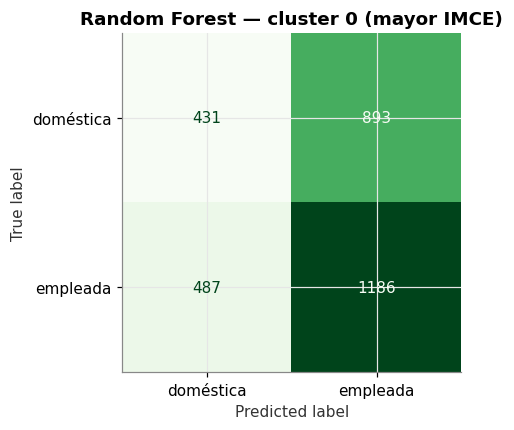

In [ ]:
# Re-estimación del MEJOR modelo de P5 (data-driven) sobre el subgrupo
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(
    Xs, ys, test_size=0.25, stratify=ys, random_state=RANDOM_STATE)

# Reutilizamos exactamente la configuración del mejor modelo determinado en P5 (clonado y
# reentrenado desde cero sobre el subgrupo). NO se hardcodea XGBoost.
best_p7 = clone(modelos[mejor_modelo])
print(f"Re-estimando el mejor modelo de P5 = '{mejor_modelo}' sobre el cluster {cluster_top}")
best_p7.fit(Xs_tr, ys_tr)
yp = best_p7.predict(Xs_te)
print(classification_report(ys_te, yp, target_names=["doméstica", "empleada"]))

# F1 ponderado: subgrupo (P7) vs global (P5) para el MISMO modelo
f1_sub = f1_score(ys_te, yp, average="weighted")
f1_glob = tabla_p5.loc[mejor_modelo, "f1_weighted"]
print(f"\nF1 ponderado  ->  P7 (cluster {cluster_top}): {f1_sub:.4f}  |  "
      f"P5 (global): {f1_glob:.4f}  |  Δ = {f1_sub - f1_glob:+.4f}")

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(confusion_matrix(ys_te, yp),
                       display_labels=["doméstica", "empleada"]).plot(
    ax=ax, cmap="Greens", colorbar=False)
ax.set_title(f"{mejor_modelo}, cluster {cluster_top} (mayor IMCE)")
plt.show()

Lectura de P7. El mejor modelo de P5 fue Random Forest (selección data-driven, no
hardcodeada). Re-estimado sobre el cluster 0 (mayor IMCE; subgrupo de 11.987 casos, target
6.692 empleada / 5.295 doméstica), alcanza F1 ponderado 0.5228, frente a 0.5321 del mismo
modelo a nivel global (Δ = −0.009): el desempeño se degrada levemente. Restringir a la
población de mayor IMCE no aporta señal adicional sobre el empleo materno; al contrario, con
menos datos el modelo rinde un poco peor. Esto refuerza la conclusión de P4–P5: las features
socioemocionales tienen poder predictivo limitado sobre madre_work, también dentro del subgrupo
de mayor riesgo nutricional.


## P8. NLP sobre narrative con SVC (sin variables sk)

Nota sobre Sentiment_Analysis.ipynb. El notebook de referencia esta incluido en la carpeta
y se uso como guia metodologica: limpieza de texto, remocion de stopwords en espanol,
vectorizacion y entrenamiento de un SVC lineal. En particular, se adapta la funcion de
tokenizacion tipo tweet_to_words del notebook: normaliza texto y filtra caracteres no
alfabeticos; la remocion de stopwords se aplica en el vectorizador. La unica mejora deliberada
es reemplazar CountVectorizer por TF-IDF para ponderar mejor los terminos en texto disperso.

Entrenamos un SVC lineal para predecir madre_work (mismo target binario que P5),
excluyendo las variables sk. Asi contrastamos features de texto vs features factoriales.

Pipeline NLP (robusto y eficiente):
1. Limpieza/tokenizacion: funcion autocontenida inspirada en tweet_to_words: minusculas,
   eliminacion de tildes/acentos, signos y digitos.
2. Vectorizacion: TfidfVectorizer con n-gramas (1,2), stop_words en espanol y poda de
   vocabulario (min_df, max_df) para controlar dimensionalidad y ruido.
3. Modelo: LinearSVC (SVC con kernel lineal, mucho mas rapido en texto disperso de alta
   dimension) con C optimizado por validacion cruzada - el analogo en texto del SVC de P5.


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

# Stopwords en español (lista compacta y autocontenida)
STOP_ES = """a al algo algunas algunos ante antes como con contra cual cuando de del desde donde
dos el ella ellas ellos en entre era erais eran eres es esa esas ese eso esos esta estaba estado
estan estar este esto estos fue fui ha hace hasta hay la las le les lo los mas me mi mientras mucho
muy nada ni no nos o os otra otras otro otros para pero poco por porque que se sea sin sobre solo
su sus tambien tan tanto te tiene tienen toda todas todo todos tu un una uno unos y ya""".split()

def tokenizar_sentiment_ref(texto):
    """Adaptación autocontenida de tweet_to_words() del notebook Sentiment_Analysis."""
    t = texto.lower()
    t = "".join(c for c in unicodedata.normalize("NFKD", t)
                if not unicodedata.combining(c))      # quitar tildes
    t = re.sub(r"[^a-z\s]", " ", t)                   # solo letras
    return re.sub(r"\s+", " ", t).strip()

# Datos: texto + target binario (excluye desempleadas y variables sk)
df_txt = df_clean[df_clean["madre_work"] != 0].copy()
df_txt["clean"] = df_txt["narrative"].apply(tokenizar_sentiment_ref)
y_txt = (df_txt["madre_work"] == 1).astype(int).values
print("Ejemplo limpio:\n", df_txt["clean"].iloc[0][:160], "...")

Ejemplo limpio:
 las habilidades socioemocionales estan bien establecidas con lo afectivo emocional como area mas fuerte y la curiosidad e intereses cognitivos como la mas rezag ...


In [ ]:
# Split y vectorización TF-IDF
# pandas>=3 usa dtype string (Arrow) por defecto: forzamos ndarray de objetos para que
# el indexado de scikit-learn (train_test_split) funcione sin TypeError.
Xtr_raw, Xte_raw, ytr, yte = train_test_split(
    df_txt["clean"].to_numpy(dtype=object), y_txt, test_size=0.25,
    stratify=y_txt, random_state=RANDOM_STATE)

vectorizer = TfidfVectorizer(stop_words=STOP_ES, ngram_range=(1, 2),
                             min_df=5, max_df=0.9, sublinear_tf=True)
Xtr = vectorizer.fit_transform(Xtr_raw)
Xte = vectorizer.transform(Xte_raw)
print("Matriz TF-IDF:", Xtr.shape, "| vocabulario:", len(vectorizer.vocabulary_))

Matriz TF-IDF: (28158, 1197) | vocabulario: 1197


Mejor C: 0.1 | F1(CV): 0.5160 | t=16.4s
              precision    recall  f1-score   support

   domestica       0.47      0.51      0.49      4257
    empleada       0.56      0.53      0.54      5130

    accuracy                           0.52      9387
   macro avg       0.52      0.52      0.52      9387
weighted avg       0.52      0.52      0.52      9387



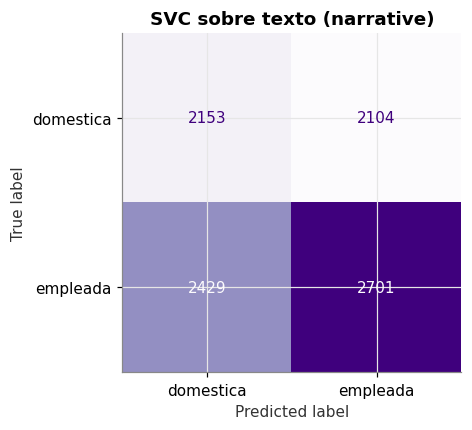

In [ ]:
# SVC lineal con optimizacion de C (k-fold)
svc = LinearSVC(class_weight="balanced", random_state=RANDOM_STATE)
grid_svc = GridSearchCV(svc, {"C": [0.1, 0.5, 1, 2]},
                        cv=5, scoring="f1_weighted", n_jobs=-1)
t0 = time.time(); grid_svc.fit(Xtr, ytr); t_svc = time.time() - t0
print(f"Mejor C: {grid_svc.best_params_['C']} | F1(CV): {grid_svc.best_score_:.4f} | t={t_svc:.1f}s")

yp = grid_svc.predict(Xte)
print(classification_report(yte, yp, target_names=["domestica", "empleada"]))

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(confusion_matrix(yte, yp),
                       display_labels=["domestica", "empleada"]).plot(
    ax=ax, cmap="Purples", colorbar=False)
ax.set_title("SVC sobre texto (narrative)")
plt.show()


In [ ]:
# Términos más discriminativos (interpretabilidad del SVC lineal)
coefs = grid_svc.best_estimator_.coef_[0]
vocab = np.array(vectorizer.get_feature_names_out())
top_pos = vocab[np.argsort(coefs)[-12:]][::-1]
top_neg = vocab[np.argsort(coefs)[:12]]
print("Términos que empujan a 'empleada':", list(top_pos))
print("Términos que empujan a 'doméstica':", list(top_neg))

Términos que empujan a 'empleada': ['libros participacion', 'artisticas observan', 'adultos armar', 'ambitos mejor', 'rezagada senales', 'regularidad destaca', 'favorable curiosidad', 'persistente resalta', 'entorno siendo', 'sentimientos interes', 'especificas agresividad', 'cosas compartir']
Términos que empujan a 'doméstica': ['pares agresividad', 'sentimientos siendo', 'desarrollo apoyado', 'padres participacion', 'grupales compartir', 'intermedio ventaja', 'sostenidas resalta', 'ausente destaca', 'ausente conductas', 'padres armar', 'entorno afecto', 'moderado ventaja']


El TF-IDF (1.197 features, n-gramas 1–2) con
LinearSVC, es decir, un SVC lineal eficiente para TF-IDF disperso (mejor C = 0.1) logra en el hold-out F1 ponderado 0.5181 (accuracy 0.5171).
Los números reales confirman la similitud con P5:

- vs SVM (RBF) tabular de P5 (F1 0.5117): el texto rinde marginalmente mejor (+0.007).
- vs el mejor modelo de P5 (Random Forest, F1 0.5321): el texto queda levemente por debajo.
- Todas las fuentes caen en la misma banda estrecha (~0.51–0.53): ninguna contiene señal fuerte
  sobre el empleo materno, coherente con que narrative es una reformulación verbal de los mismos
  sk1–sk13.

Cautela sobre los bigramas. El texto es sintético/generado a partir de los ítems sk, por
lo que los n-gramas "discriminativos" (p. ej. cosas compartir, pares agresividad) reflejan
plantillas del generador, no expresiones espontáneas; no deben sobre-interpretarse como
hallazgos lingüísticos.

Conclusión global: la estructura socioemocional, como 3 factores del CFA o como texto, tiene
poder predictivo limitado sobre madre_work (todos los modelos ~0.51–0.53 de F1). Bajo el
criterio explícito (mayor F1, desempate por tiempo) el mejor modelo es Random Forest, con
XGBoost como alternativa casi idéntica y mucho más rápida.
